In [1]:
import pandas as pd
df =pd.read_csv("water_dataX.csv",encoding="latin1",na_values=["NAN","nan","Nan"])
print(df.shape)
df.head()

(1991, 12)


,STATION CODE,LOCATIONS,STATE,Temp,D.O. (mg/l),PH,CONDUCTIVITY (¦Ìmhos/cm),B.O.D. (mg/l),NITRATENAN N+ NITRITENANN (mg/l),FECAL COLIFORM (MPN/100ml),TOTAL COLIFORM (MPN/100ml)Mean,year
0,1393.0,"DAMANGANGA AT D/S OF MADHUBAN, DAMAN",DAMAN & DIU,30.6,6.7,7.5,203.0,NaN,0.1,11,27,2014
1,1399.0,ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOI...,GOA,29.8,5.7,7.2,189.0,2,0.2,4953,8391,2014
2,1475.0,ZUARI AT PANCHAWADI,GOA,29.5,6.3,6.9,179.0,1.7,0.1,3243,5330,2014
3,3181.0,RIVER ZUARI AT BORIM BRIDGE,GOA,29.7,5.8,6.9,64.0,3.8,0.5,5382,8443,2014
4,3182.0,RIVER ZUARI AT MARCAIM JETTY,GOA,29.5,5.8,7.3,83.0,1.9,0.4,3428,5500,2014


In [7]:
df.describe()
print(df.isnull().sum())
print("---") # 每列空值
print("总行数：", len(df))

STATION CODE                        122
LOCATIONS                           184
STATE                               761
Temp                                 88
D.O. (mg/l)                          31
PH                                    8
CONDUCTIVITY (¦Ìmhos/cm)             25
B.O.D. (mg/l)                        40
NITRATENAN N+ NITRITENANN (mg/l)    220
FECAL COLIFORM (MPN/100ml)          303
TOTAL COLIFORM (MPN/100ml)Mean      121
year                                  0
dtype: int64
---
总行数： 1991


In [8]:
print(df.columns.tolist())

['STATION CODE', 'LOCATIONS', 'STATE', 'Temp', 'D.O. (mg/l)', 'PH', 'CONDUCTIVITY (¦Ìmhos/cm)', 'B.O.D. (mg/l)', 'NITRATENAN N+ NITRITENANN (mg/l)', 'FECAL COLIFORM (MPN/100ml)', 'TOTAL COLIFORM (MPN/100ml)Mean', 'year']


In [3]:
import pandas as pd

df = pd.read_csv("water_dataX.csv",
                 encoding="latin1",
                 na_values=["NAN", "nan", "Nan", " ", ""])

# 删全空行
df = df.dropna(how="all")

# 第4列=Temp, 第5列=DO, 第6列=PH, 第7列=CONDUCTIVITY, 第8列=BOD, 第9列=硝酸盐
cols_to_fill = df.columns[[3,4,5,6,7,8]]

# 强制转成数字，转不了的变NaN
df[cols_to_fill] = df[cols_to_fill].apply(pd.to_numeric, errors='coerce')

# 均值填充
df_clean = df.copy()
df_clean[cols_to_fill] = df_clean[cols_to_fill].fillna(
    df_clean[cols_to_fill].mean()
)

print(df_clean[cols_to_fill].isnull().sum())
print("清洗完成！")


Temp                                0
D.O. (mg/l)                         0
PH                                  0
CONDUCTIVITY (¦Ìmhos/cm)            0
B.O.D. (mg/l)                       0
NITRATENAN N+ NITRITENANN (mg/l)    0
dtype: int64
清洗完成！


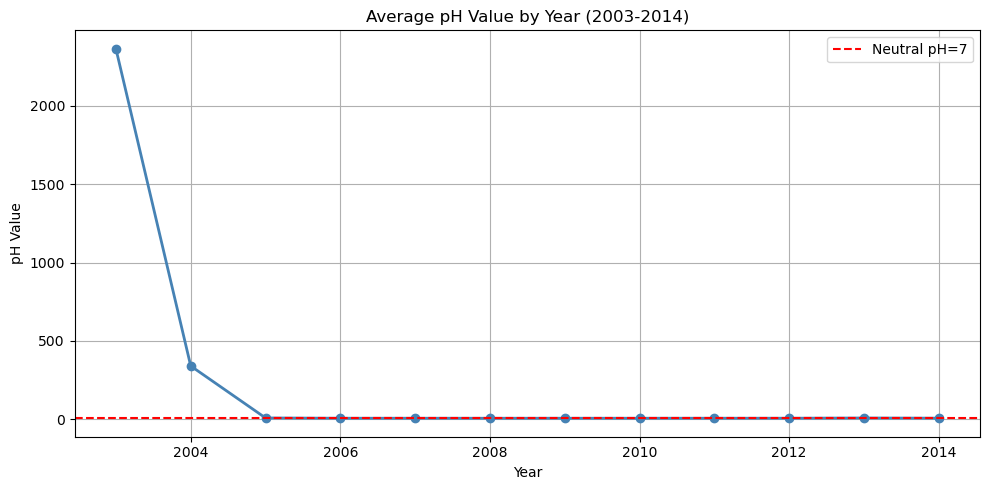

In [4]:
import matplotlib.pyplot as plt

# 每年pH平均值变化趋势
ph_by_year = df_clean.groupby("year")["PH"].mean()

plt.figure(figsize=(10, 5))
plt.plot(ph_by_year.index, ph_by_year.values, 
         marker="o", color="steelblue", linewidth=2)

plt.title("Average pH Value by Year (2003-2014)")
plt.xlabel("Year")
plt.ylabel("pH Value")
plt.axhline(y=7, color="red", linestyle="--", label="Neutral pH=7")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()